In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import pyccl as ccl

In [2]:
#Get theory prediction for the correlation function
def compute_xi(omega_m, sigma_8, a, theta_arcmin):
    #Define the cosmology
    h0 = 0.6727
    ombh2 = 0.02236
    n_s = 0.9649
    omega_b = ombh2 / h0**2
    tau = 0.0544
    cosmo = ccl.Cosmology(
        Omega_c = omega_m - omega_b,
        Omega_b = omega_b,
        h = h0,
        n_s = n_s,
        sigma8 = sigma_8,
        Omega_k = 0.,
        w0 = -1.,
        wa = 0.,
        transfer_function='eisenstein_hu',
    )


    #Define the redshift distribution
    z, dndz = np.loadtxt('/home/guerrini/sp_validation/cosmo_inference/cosmocov_config/dndz_test.txt', unpack=True)

    tracer = ccl.WeakLensingTracer(cosmo, (z, dndz), ia_bias=None)

    #COmpute the angular power spectrum C_ell
    ell = np.logspace(0, np.log10(10000), 1000)
    cl_gg = ccl.angular_cl(cosmo, tracer, tracer, ell)

    #Compute the 2PCF
    theta_deg = theta_arcmin / 60
    #xi+ fit
    xi_p_theta = ccl.correlation(cosmo, ell, cl_gg, theta_deg, type='GG+')
    #xi- fit
    xi_m_theta = ccl.correlation(cosmo, ell, cl_gg, theta_deg, type='GG-')

    return xi_p_theta, xi_m_theta

def get_xi_sys(alpha, beta, rho_stats):
    xi_sys_plus = alpha**2 * rho_stats['rho_0_p'] + beta**2 * rho_stats['rho_1_p'] + 2*alpha*beta*rho_stats['rho_2_p']
    xi_sys_minus = alpha**2 * rho_stats['rho_0_m'] + beta**2 * rho_stats['rho_1_m'] + 2*alpha*beta*rho_stats['rho_2_m']
    return xi_sys_plus, xi_sys_minus

In [3]:
theta = fits.getdata('/home/guerrini/sp_validation/notebooks/cosmo_val/output/xi_plus_SP_v1.4.1.fits')['ANG']

In [4]:
Omega_m = 0.3
sigma_8 = 0.8

synthetic_xi_plus, synthetic_xi_minus= compute_xi(omega_m=Omega_m, sigma_8=sigma_8, a=1, theta_arcmin=theta)

/home/guerrini/.conda/envs/sp_validation/lib/python3.9/site-packages/pyccl/tracers.py:110: CCLWarning: The number of samples in the n(z) (201) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False
  warnings.warn(


In [5]:
alpha_loc, alpha_scale = 0.016, 0.002
beta_loc, beta_scale = 1.05, 0.091

alpha = np.random.normal(alpha_loc, alpha_scale)
beta = np.random.normal(beta_loc, beta_scale)
print("alpha: ", alpha)
print("beta: ", beta)

rho_stats = fits.getdata('/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/rho_stats_SP_v1.4.1.fits')

xi_sys_plus, xi_sys_minus = get_xi_sys(alpha_loc, beta_loc, rho_stats)

alpha:  0.01576757498674661
beta:  1.0329969180797671


In [6]:
synthetic_xi_plus = synthetic_xi_plus + xi_sys_plus
synthetic_xi_minus = synthetic_xi_minus + xi_sys_minus
cov_mat = fits.open('/home/guerrini/sp_validation/cosmo_inference/data/SP_v1.4.1/cosmosis_SP_v1.4.1.fits')['COVMAT'].data

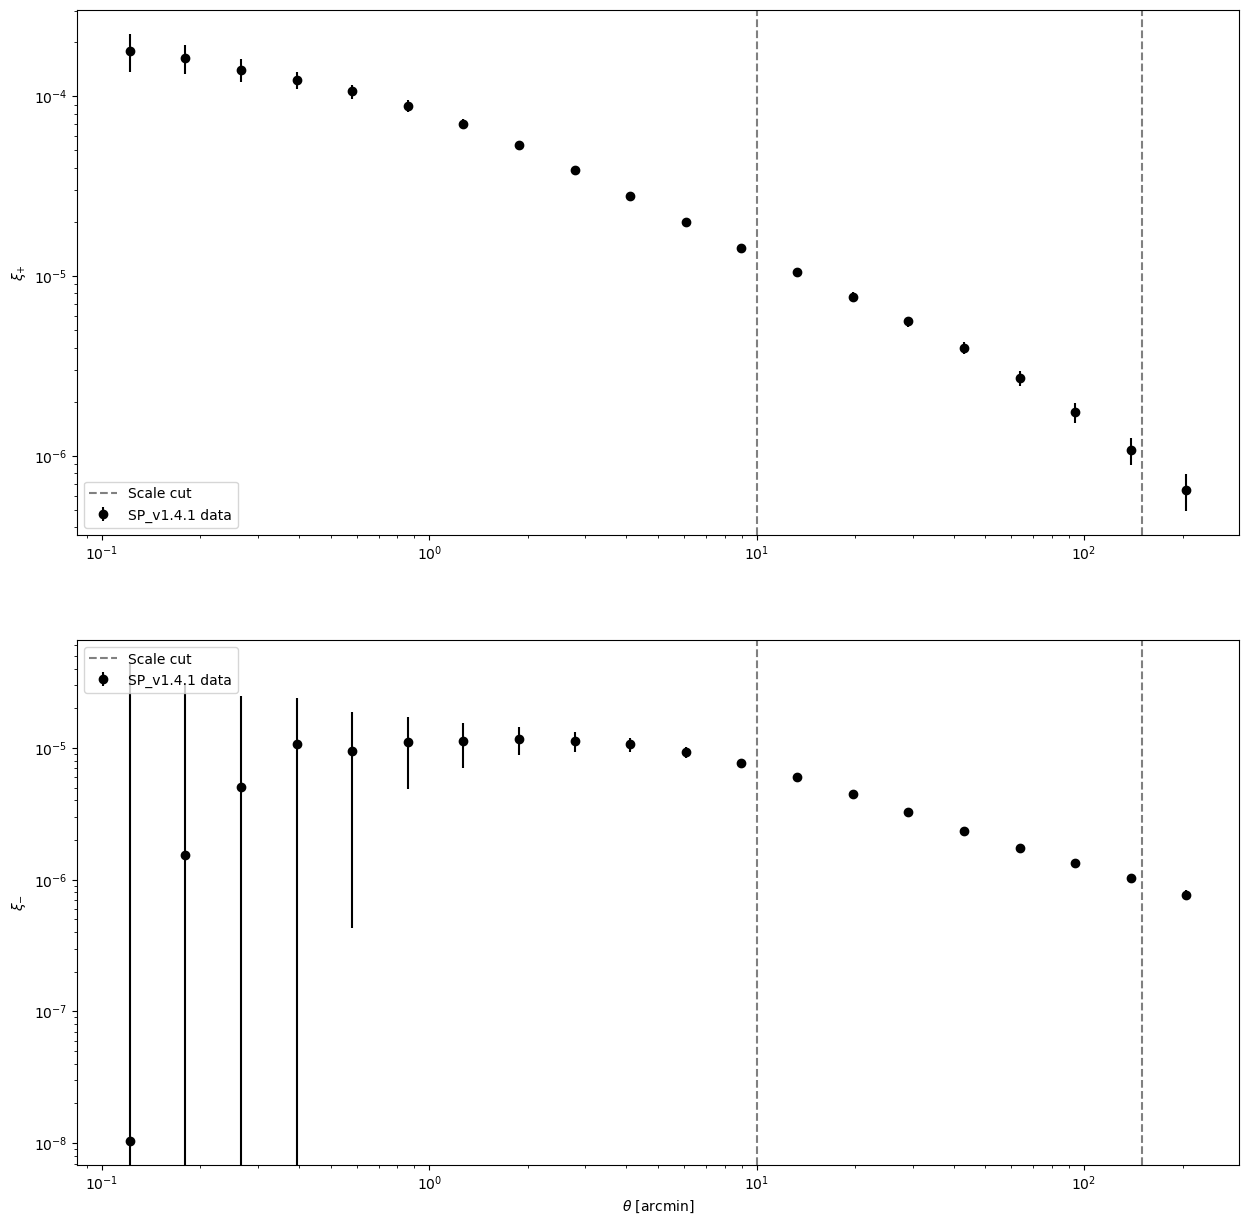

In [7]:
plt.figure(figsize=(15, 15))

plt.subplot(211)

plt.errorbar(theta, synthetic_xi_plus, yerr=np.sqrt(np.diag(cov_mat))[:20], fmt='o', label='SP_v1.4.1 data', color='black')

plt.axvline(10.0, color='grey', linestyle='--', label='Scale cut')
plt.axvline(150.0, color='grey', linestyle='--')

plt.ylabel(r'$\xi_{+}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(212)

plt.errorbar(theta, synthetic_xi_minus, yerr=np.sqrt(np.diag(cov_mat))[20:40], fmt='o', label='SP_v1.4.1 data', color='black')

plt.axvline(10.0, color='grey', linestyle='--', label='Scale cut')
plt.axvline(150.0, color='grey', linestyle='--')

plt.xlabel(r'$\theta$ [arcmin]')
plt.ylabel(r'$\xi_{-}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

In [9]:
nbins = len(theta)
lst = np.arange(1, nbins+1)

#Create fits HDU for tau_0_+
col1 = fits.Column(name ='BIN1', format ='K', array = np.ones(len(lst)))
col2 = fits.Column(name ='BIN2', format ='K', array = np.ones(len(lst)))
col3 = fits.Column(name ='ANGBIN', format ='K', array = lst)
col4 = fits.Column(name = 'VALUE', format = 'D', array = synthetic_xi_plus)
col5 = fits.Column(name = 'ANG', format = 'D', unit='arcmin', array = theta)
coldefs = fits.ColDefs([col1, col2, col3, col4, col5])
xi_plus_hdu = fits.BinTableHDU.from_columns(coldefs, name='XI_PLUS')

col4 = fits.Column(name = 'VALUE', format = 'D', array = synthetic_xi_minus)
coldefs = fits.ColDefs([col1, col2, col3, col4, col5])
xi_minus_hdu = fits.BinTableHDU.from_columns(coldefs, name='XI_MINUS')

xi_plus_dict =  {
        '2PTDATA' : 'T',
        'QUANT1' : 'G+R',
        'QUANT2' : 'G+R',
        'KERNEL_1': 'NZ_SOURCE',
        'KERNEL_2': 'NZ_SOURCE',
        'WINDOWS': 'SAMPLE'
    }
for key in xi_plus_dict:
    xi_plus_hdu.header[key] = xi_plus_dict[key]

xi_minus_dict =  {
    '2PTDATA' : 'T',
    'QUANT1' : 'G-R',
    'QUANT2' : 'G-R',
    'KERNEL_1': 'NZ_SOURCE',
    'KERNEL_2': 'NZ_SOURCE',
    'WINDOWS': 'SAMPLE'
}

for key in xi_minus_dict:
    xi_minus_hdu.header[key] = xi_minus_dict[key]

xi_plus_hdu.writeto('/home/guerrini/sp_validation/cosmo_inference/data/fake_SP_v1.4.1_2/xi_plus_fake_SP_v1.4.1_2.fits', overwrite=True)
xi_minus_hdu.writeto('/home/guerrini/sp_validation/cosmo_inference/data/fake_SP_v1.4.1_2/xi_minus_fake_SP_v1.4.1_2.fits', overwrite=True)